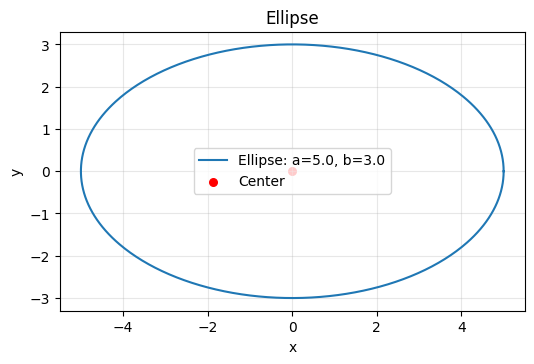

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Ellipse parameters
semi_major = 5.0   # a
semi_minor = 3.0   # b
x0, y0 = 0.0, 0.0  # center

# Parametric ellipse
t = np.linspace(0, 2 * np.pi, 600)
x = x0 + semi_major * np.cos(t)
y = y0 + semi_minor * np.sin(t)

plt.figure(figsize=(6, 6))
plt.plot(x, y, label=f"Ellipse: a={semi_major}, b={semi_minor}")
plt.scatter([x0], [y0], color="red", s=30, label="Center")
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ellipse")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_rotated_ellipse(a=5.0, b=3.0, theta_deg=0.0, x0=0.0, y0=0.0):
    t = np.linspace(0, 2 * np.pi, 800)

    # Axis-aligned ellipse
    x = a * np.cos(t)
    y = b * np.sin(t)

    # Rotate by theta and translate to (x0, y0)
    theta = np.deg2rad(theta_deg)
    xr = x * np.cos(theta) - y * np.sin(theta) + x0
    yr = x * np.sin(theta) + y * np.cos(theta) + y0

    plt.figure(figsize=(6, 6))
    plt.plot(xr, yr, label=f"Ellipse: a={a:.2f}, b={b:.2f}, θ={theta_deg:.1f}°")
    plt.scatter([x0], [y0], color="red", s=30, label="Center")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlim(x0 - (a + b + 1), x0 + (a + b + 1))
    plt.ylim(y0 - (a + b + 1), y0 + (a + b + 1))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interactive Rotated & Translated Ellipse")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.show()

interact(
    plot_rotated_ellipse,
    a=FloatSlider(value=5.0, min=0.5, max=10.0, step=0.1, description="a"),
    b=FloatSlider(value=3.0, min=0.5, max=10.0, step=0.1, description="b"),
    theta_deg=FloatSlider(value=30.0, min=-180.0, max=180.0, step=1.0, description="theta"),
    x0=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1, description="x0"),
    y0=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1, description="y0"),
);

interactive(children=(FloatSlider(value=5.0, description='a', max=10.0, min=0.5), FloatSlider(value=3.0, descr…

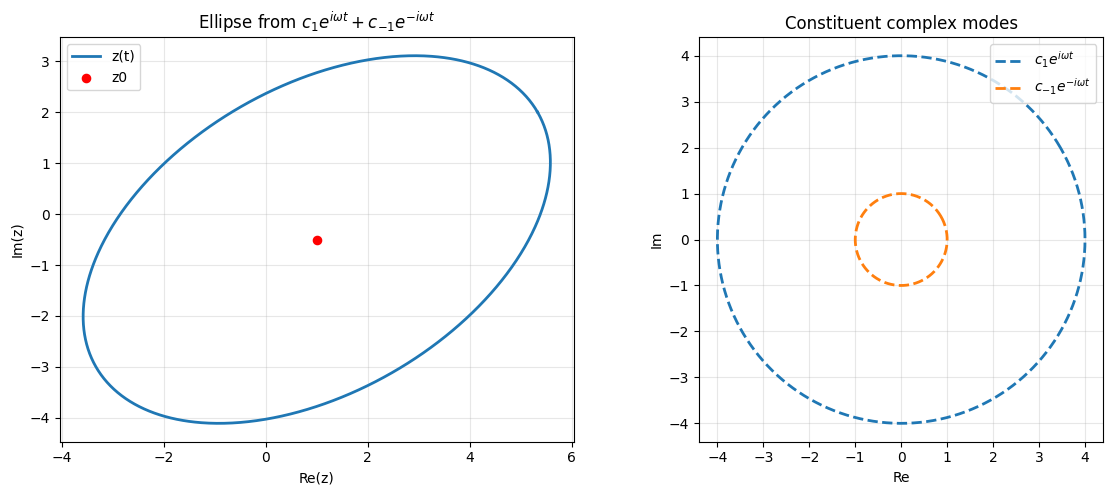

Decomposition:
z(t) = z0 + c1*exp(i*w*t) + c_-1*exp(-i*w*t),   w=1.0
z0   = 1.0000-0.5000j
c1   = 3.4641+2.0000j
c_-1 = 0.8660+0.5000j


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
w = 1.0
a = 5.0
b = 3.0
theta_deg = 30.0
x0, y0 = 1.0, -0.5
z0 = x0 + 1j * y0

t = np.linspace(0, 2 * np.pi, 1200)
theta = np.deg2rad(theta_deg)

# Mode coefficients for a rotated ellipse:
# z(t) = z0 + c1*exp(i*w*t) + c_minus1*exp(-i*w*t)
c1 = 0.5 * (a + b) * np.exp(1j * theta)
c_minus1 = 0.5 * (a - b) * np.exp(1j * theta)

mode_plus = c1 * np.exp(1j * w * t)
mode_minus = c_minus1 * np.exp(-1j * w * t)
z = z0 + mode_plus + mode_minus

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: final ellipse in complex plane
axes[0].plot(z.real, z.imag, color="tab:blue", lw=2, label="z(t)")
axes[0].scatter([z0.real], [z0.imag], color="red", s=35, label="z0")
axes[0].set_title(r"Ellipse from $c_1e^{i\omega t}+c_{-1}e^{-i\omega t}$")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right: individual +/- modes (centered at origin)
axes[1].plot(mode_plus.real, mode_plus.imag, "--", lw=2, label=r"$c_1 e^{i\omega t}$")
axes[1].plot(mode_minus.real, mode_minus.imag, "--", lw=2, label=r"$c_{-1} e^{-i\omega t}$")
axes[1].set_title("Constituent complex modes")
axes[1].set_xlabel("Re")
axes[1].set_ylabel("Im")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Decomposition:")
print(f"z(t) = z0 + c1*exp(i*w*t) + c_-1*exp(-i*w*t),   w={w}")
print(f"z0   = {z0:.4f}")
print(f"c1   = {c1:.4f}")
print(f"c_-1 = {c_minus1:.4f}")

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Approximate orbital elements (semi-major axis a in AU, eccentricity e)
planet_orbits = {
    "Mercury": {"a": 0.387, "e": 0.2056, "omega_deg": 29.1},
    "Venus":   {"a": 0.723, "e": 0.0068, "omega_deg": 54.9},
    "Earth":   {"a": 1.000, "e": 0.0167, "omega_deg": 102.9},
    "Mars":    {"a": 1.524, "e": 0.0934, "omega_deg": -23.9},
    "Jupiter": {"a": 5.203, "e": 0.0489, "omega_deg": 14.8},
    "Saturn":  {"a": 9.537, "e": 0.0565, "omega_deg": 92.4},
    "Uranus":  {"a": 19.191, "e": 0.0472, "omega_deg": 170.9},
    "Neptune": {"a": 30.070, "e": 0.0086, "omega_deg": 44.9},
}

def plot_planet_orbit_complex(name, a, e, omega_deg=0.0):
    nu = np.linspace(0, 2 * np.pi, 1600)
    r = a * (1 - e**2) / (1 + e * np.cos(nu))
    omega = np.deg2rad(omega_deg)
    z = r * np.exp(1j * (nu + omega))

    plt.figure(figsize=(6, 6))
    plt.plot(z.real, z.imag, lw=2, label=f"{name} orbit")
    plt.scatter([0], [0], color="gold", edgecolor="black", s=90, zorder=3, label="Sun (focus)")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("Re(z) [AU]")
    plt.ylabel("Im(z) [AU]")
    plt.title(f"{name} Orbit in the Complex Plane")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.show()

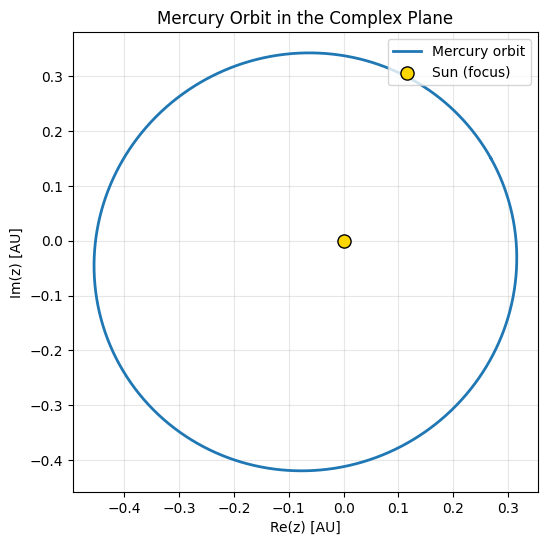

In [11]:
plot_planet_orbit_complex("Mercury", **planet_orbits["Mercury"])

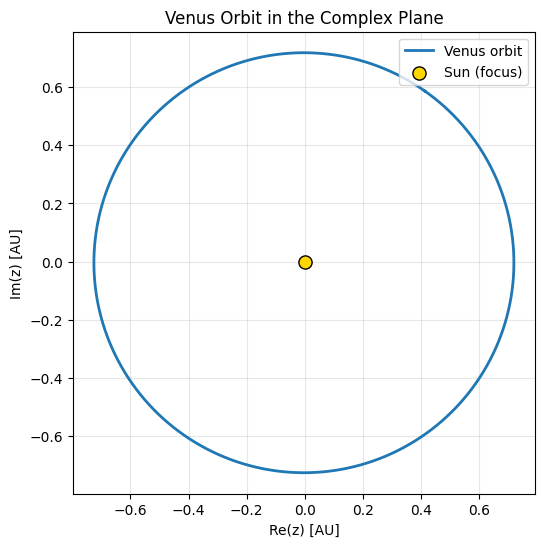

In [12]:
plot_planet_orbit_complex("Venus", **planet_orbits["Venus"])

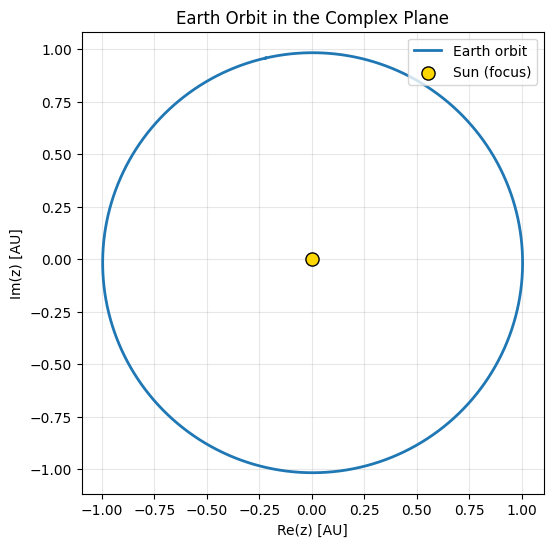

In [13]:
plot_planet_orbit_complex("Earth", **planet_orbits["Earth"])

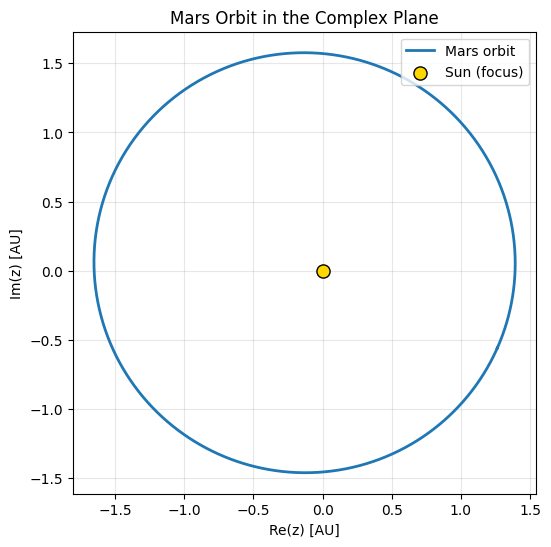

In [14]:
plot_planet_orbit_complex("Mars", **planet_orbits["Mars"])

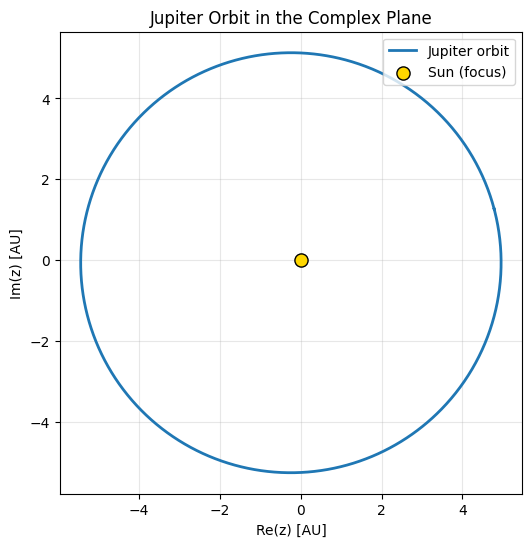

In [15]:
plot_planet_orbit_complex("Jupiter", **planet_orbits["Jupiter"])

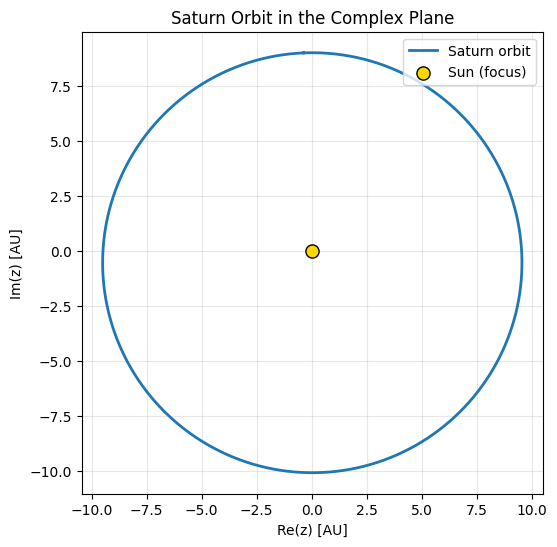

In [16]:
plot_planet_orbit_complex("Saturn", **planet_orbits["Saturn"])

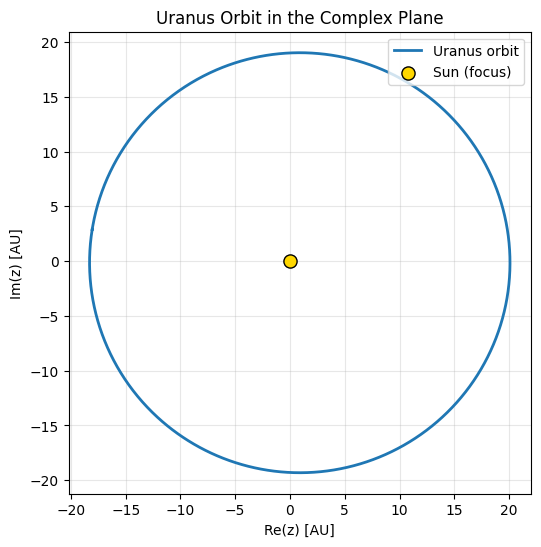

In [17]:
plot_planet_orbit_complex("Uranus", **planet_orbits["Uranus"])

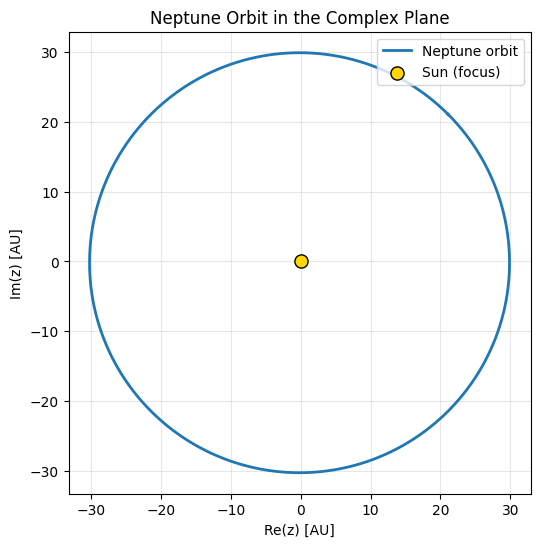

In [18]:
plot_planet_orbit_complex("Neptune", **planet_orbits["Neptune"])

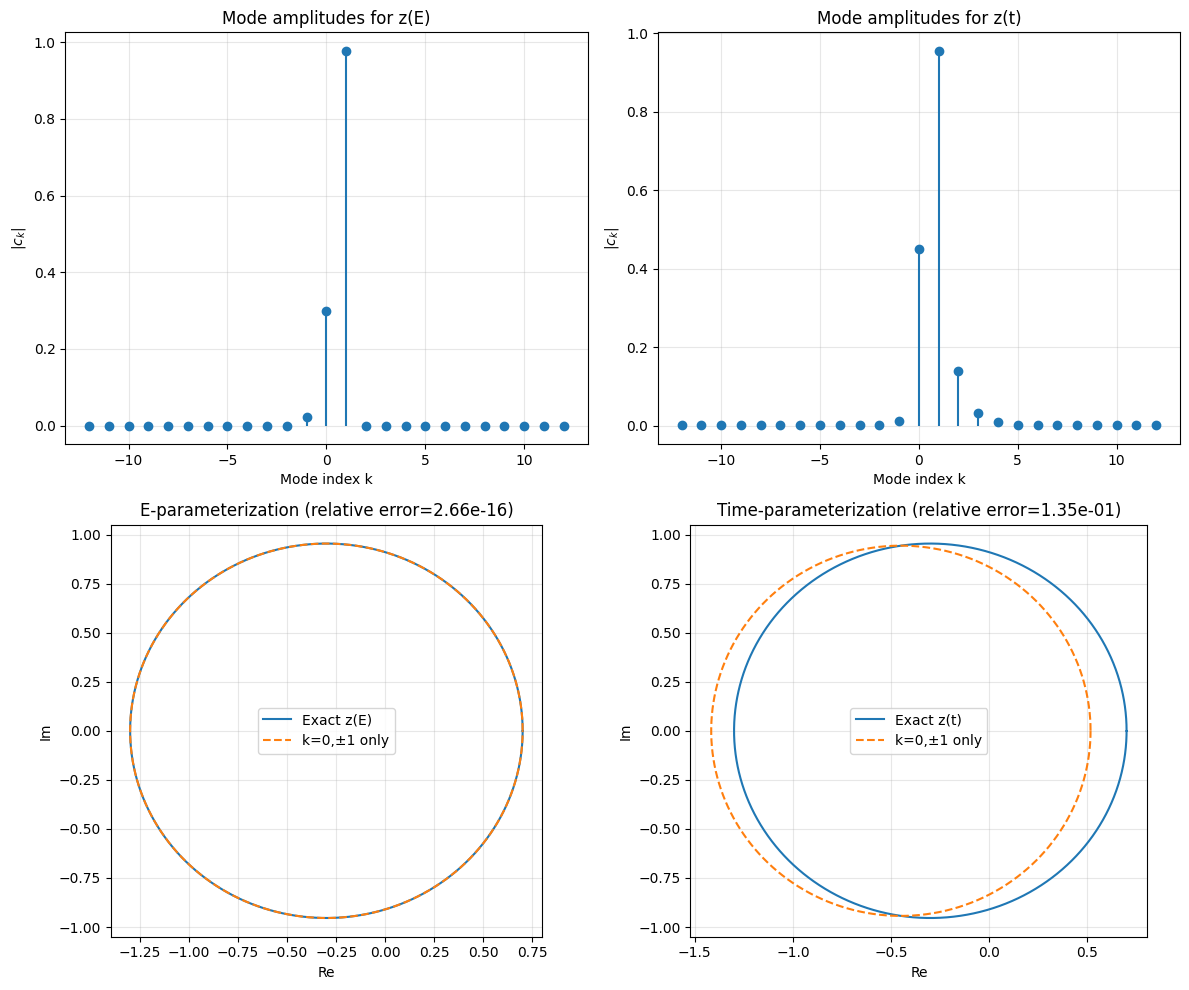

Answer:
- For z(E): ellipse is exactly represented by k=0,±1 (two oscillatory modes + constant).
- For z(t): generally NOT just two modes; higher harmonics are needed when e > 0.
- Relative error using only k=0,±1: z(E)=2.66e-16, z(t)=1.35e-01


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Example eccentricity (set to 0 for circular orbit)
a = 1.0
e = 0.30
b = a * np.sqrt(1 - e**2)
N = 4096

# ---------- 1) Parameterization by eccentric anomaly E ----------
E = np.linspace(0, 2 * np.pi, N, endpoint=False)
z_E = a * (np.cos(E) - e) + 1j * b * np.sin(E)  # focus at origin

# ---------- 2) Parameterization by physical time t (via mean anomaly M) ----------
M = np.linspace(0, 2 * np.pi, N, endpoint=False)  # M = n t (linear in time)
E_t = M.copy()
for _ in range(12):  # Newton solve: E - e sin(E) = M
    E_t -= (E_t - e * np.sin(E_t) - M) / (1 - e * np.cos(E_t))

z_t = a * (np.cos(E_t) - e) + 1j * b * np.sin(E_t)

# Fourier modes (integer mode index k over one period)
k = np.fft.fftfreq(N, d=1 / N).astype(int)
C_E = np.fft.fft(z_E) / N
C_t = np.fft.fft(z_t) / N

# Keep only k = 0, ±1 ("two oscillatory modes" + constant shift)
mask_3 = (k == 0) | (k == 1) | (k == -1)
Z_E = np.fft.fft(z_E)
Z_t = np.fft.fft(z_t)

z_E_3mode = np.fft.ifft(Z_E * mask_3)
z_t_3mode = np.fft.ifft(Z_t * mask_3)

rel_err_E = np.linalg.norm(z_E - z_E_3mode) / np.linalg.norm(z_E)
rel_err_t = np.linalg.norm(z_t - z_t_3mode) / np.linalg.norm(z_t)

# Plot spectra and reconstructions
kmax = 12
sel = (k >= -kmax) & (k <= kmax)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].stem(k[sel], np.abs(C_E[sel]), basefmt=" ")
axes[0, 0].set_title("Mode amplitudes for z(E)")
axes[0, 0].set_xlabel("Mode index k")
axes[0, 0].set_ylabel(r"$|c_k|$")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].stem(k[sel], np.abs(C_t[sel]), basefmt=" ")
axes[0, 1].set_title("Mode amplitudes for z(t)")
axes[0, 1].set_xlabel("Mode index k")
axes[0, 1].set_ylabel(r"$|c_k|$")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(z_E.real, z_E.imag, label="Exact z(E)")
axes[1, 0].plot(z_E_3mode.real, z_E_3mode.imag, "--", label="k=0,±1 only")
axes[1, 0].set_title(f"E-parameterization (relative error={rel_err_E:.2e})")
axes[1, 0].set_xlabel("Re")
axes[1, 0].set_ylabel("Im")
axes[1, 0].set_aspect("equal", adjustable="box")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(z_t.real, z_t.imag, label="Exact z(t)")
axes[1, 1].plot(z_t_3mode.real, z_t_3mode.imag, "--", label="k=0,±1 only")
axes[1, 1].set_title(f"Time-parameterization (relative error={rel_err_t:.2e})")
axes[1, 1].set_xlabel("Re")
axes[1, 1].set_ylabel("Im")
axes[1, 1].set_aspect("equal", adjustable="box")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Answer:")
print("- For z(E): ellipse is exactly represented by k=0,±1 (two oscillatory modes + constant).")
print("- For z(t): generally NOT just two modes; higher harmonics are needed when e > 0.")
print(f"- Relative error using only k=0,±1: z(E)={rel_err_E:.2e}, z(t)={rel_err_t:.2e}")

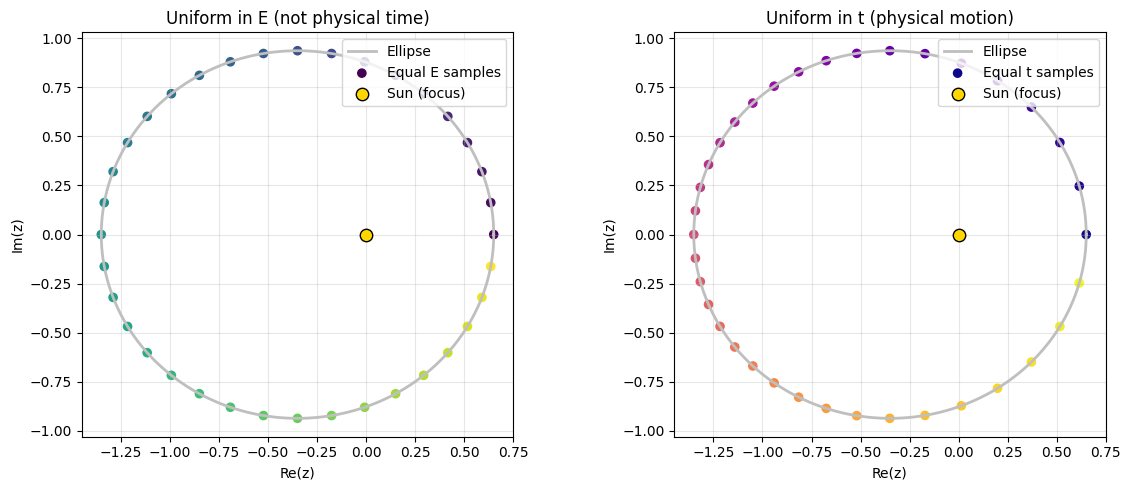

Interpretation:
- Uniform E samples are a mathematical parameterization.
- Uniform t samples represent real orbital timing (Kepler motion).
- In uniform t, points spread more near perihelion and cluster near aphelion.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Compare equal-E sampling vs equal-time sampling on the same Kepler ellipse
a = 1.0
e = 0.35
b = a * np.sqrt(1 - e**2)
N_points = 36
N_curve = 2000

# Reference ellipse (using E parameter) with focus at origin
E_curve = np.linspace(0, 2 * np.pi, N_curve)
z_curve = a * (np.cos(E_curve) - e) + 1j * b * np.sin(E_curve)

# 1) Uniform in eccentric anomaly E
E_uniform = np.linspace(0, 2 * np.pi, N_points, endpoint=False)
z_E_pts = a * (np.cos(E_uniform) - e) + 1j * b * np.sin(E_uniform)

# 2) Uniform in time t -> uniform mean anomaly M = n t
M_uniform = np.linspace(0, 2 * np.pi, N_points, endpoint=False)
E_time = M_uniform.copy()
for _ in range(15):
    E_time -= (E_time - e * np.sin(E_time) - M_uniform) / (1 - e * np.cos(E_time))

z_t_pts = a * (np.cos(E_time) - e) + 1j * b * np.sin(E_time)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: equal E
axes[0].plot(z_curve.real, z_curve.imag, color="0.75", lw=2, label="Ellipse")
axes[0].scatter(z_E_pts.real, z_E_pts.imag, c=np.arange(N_points), cmap="viridis", s=35, label="Equal E samples")
axes[0].scatter([0], [0], color="gold", edgecolor="black", s=80, zorder=3, label="Sun (focus)")
axes[0].set_title("Uniform in E (not physical time)")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# Right: equal t
axes[1].plot(z_curve.real, z_curve.imag, color="0.75", lw=2, label="Ellipse")
axes[1].scatter(z_t_pts.real, z_t_pts.imag, c=np.arange(N_points), cmap="plasma", s=35, label="Equal t samples")
axes[1].scatter([0], [0], color="gold", edgecolor="black", s=80, zorder=3, label="Sun (focus)")
axes[1].set_title("Uniform in t (physical motion)")
axes[1].set_xlabel("Re(z)")
axes[1].set_ylabel("Im(z)")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Uniform E samples are a mathematical parameterization.")
print("- Uniform t samples represent real orbital timing (Kepler motion).")
print("- In uniform t, points spread more near perihelion and cluster near aphelion.")

Mode amplitude comparison (same ellipse, different parameterization)
k    |c_k| for z(E)      |c_k| for z(t)
0    3.500000e-01      5.250000e-01
1    9.683748e-01      9.384653e-01
2    3.688997e-17      1.591860e-01
3    1.745091e-17      4.050437e-02
4    1.190073e-17      1.221498e-02
5    2.305573e-17      4.047064e-03
6    8.084543e-18      1.423589e-03
7    6.623813e-18      5.219627e-04
8    5.921428e-18      1.972936e-04


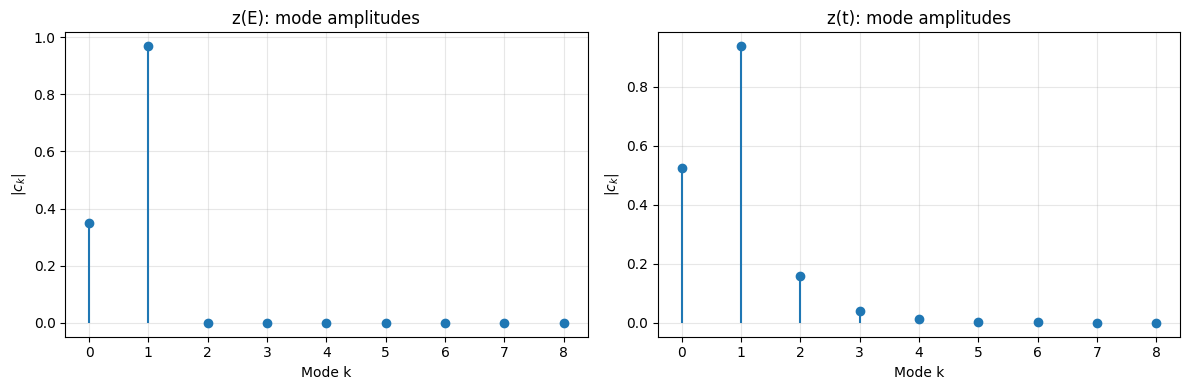


Takeaway:
- z(E): energy is concentrated in k=0 and k=1 (with matching negative mode).
- z(t): significant amplitudes appear in higher k due to nonuniform time parameterization.


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Compare mode amplitudes for z(E) vs z(t) using the same ellipse
# (same a,e as previous demo cell)
a = 1.0
e = 0.35
b = a * np.sqrt(1 - e**2)
N = 4096

# z(E): uniform in eccentric anomaly
E = np.linspace(0, 2 * np.pi, N, endpoint=False)
z_E = a * (np.cos(E) - e) + 1j * b * np.sin(E)

# z(t): uniform in time (uniform mean anomaly M)
M = np.linspace(0, 2 * np.pi, N, endpoint=False)
E_t = M.copy()
for _ in range(15):
    E_t -= (E_t - e * np.sin(E_t) - M) / (1 - e * np.cos(E_t))

z_t = a * (np.cos(E_t) - e) + 1j * b * np.sin(E_t)

# Fourier coefficients
k = np.fft.fftfreq(N, d=1 / N).astype(int)
C_E = np.fft.fft(z_E) / N
C_t = np.fft.fft(z_t) / N

# Show |c_k| for k=0..8 (positive modes)
k_show = np.arange(0, 9)
idx_show = [np.where(k == kk)[0][0] for kk in k_show]
amp_E = np.abs(C_E[idx_show])
amp_t = np.abs(C_t[idx_show])

print("Mode amplitude comparison (same ellipse, different parameterization)")
print("k    |c_k| for z(E)      |c_k| for z(t)")
for kk, aE, aT in zip(k_show, amp_E, amp_t):
    print(f"{kk:<2d}   {aE:>12.6e}      {aT:>12.6e}")

# Plot for quick visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].stem(k_show, amp_E, basefmt=" ")
axes[0].set_title("z(E): mode amplitudes")
axes[0].set_xlabel("Mode k")
axes[0].set_ylabel(r"$|c_k|$")
axes[0].grid(True, alpha=0.3)

axes[1].stem(k_show, amp_t, basefmt=" ")
axes[1].set_title("z(t): mode amplitudes")
axes[1].set_xlabel("Mode k")
axes[1].set_ylabel(r"$|c_k|$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTakeaway:")
print("- z(E): energy is concentrated in k=0 and k=1 (with matching negative mode).")
print("- z(t): significant amplitudes appear in higher k due to nonuniform time parameterization.")

z(E) expression used:
z(E) = a(cos E - e) + i a sqrt(1-e^2) sin E
a = 1.0, e = 0.35


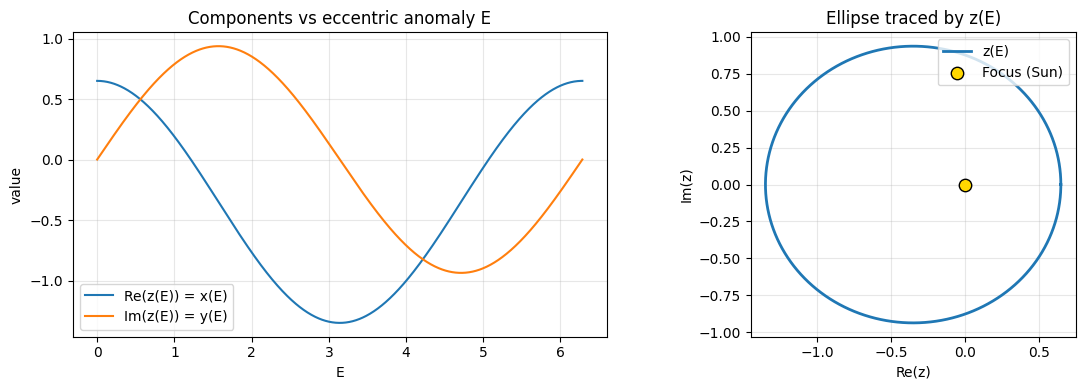

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# z(E) demo: explicit geometric expression for a Kepler ellipse
a = 1.0
e = 0.35
E = np.linspace(0, 2 * np.pi, 1000)

xE = a * (np.cos(E) - e)
yE = a * np.sqrt(1 - e**2) * np.sin(E)
zE = xE + 1j * yE

print("z(E) expression used:")
print("z(E) = a(cos E - e) + i a sqrt(1-e^2) sin E")
print(f"a = {a}, e = {e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(E, xE, label="Re(z(E)) = x(E)")
axes[0].plot(E, yE, label="Im(z(E)) = y(E)")
axes[0].set_xlabel("E")
axes[0].set_ylabel("value")
axes[0].set_title("Components vs eccentric anomaly E")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(zE.real, zE.imag, lw=2, label="z(E)")
axes[1].scatter([0], [0], color="gold", edgecolor="black", s=80, zorder=3, label="Focus (Sun)")
axes[1].set_xlabel("Re(z)")
axes[1].set_ylabel("Im(z)")
axes[1].set_title("Ellipse traced by z(E)")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()